In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
!rm -rf /content/face


In [11]:
!ls -al /content/face

ls: cannot access '/content/face': No such file or directory


In [12]:
!rsync -av --progress "/content/drive/MyDrive/cnn/face/" "/content/face/"

流式输出内容被截断，只能显示最后 5000 行内容。
          1,690 100%    2.06kB/s    0:00:00 (xfr#26212, to-chk=2498/28711)
7751.jpg
          1,589 100%    1.93kB/s    0:00:00 (xfr#26213, to-chk=2497/28711)
7752.jpg
          1,568 100%    1.90kB/s    0:00:00 (xfr#26214, to-chk=2496/28711)
7753.jpg
          1,502 100%    1.82kB/s    0:00:00 (xfr#26215, to-chk=2495/28711)
7754.jpg
          1,816 100%    2.19kB/s    0:00:00 (xfr#26216, to-chk=2494/28711)
7755.jpg
          1,594 100%    1.92kB/s    0:00:00 (xfr#26217, to-chk=2493/28711)
7756.jpg
          1,688 100%    2.03kB/s    0:00:00 (xfr#26218, to-chk=2492/28711)
7757.jpg
          1,662 100%    1.99kB/s    0:00:00 (xfr#26219, to-chk=2491/28711)
7758.jpg
          1,509 100%    1.78kB/s    0:00:00 (xfr#26220, to-chk=2490/28711)
7759.jpg
          1,652 100%    1.93kB/s    0:00:00 (xfr#26221, to-chk=2489/28711)
776.jpg
          1,335 100%    1.56kB/s    0:00:00 (xfr#26222, to-chk=2488/28711)
7760.jpg
          1,754 100%    2.04kB/s    0:00:00 (xfr#2

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 48, 48]             640
       BatchNorm2d-2           [-1, 64, 48, 48]             128
              ReLU-3           [-1, 64, 48, 48]               0
         MaxPool2d-4           [-1, 64, 24, 24]               0
            Conv2d-5           [-1, 64, 24, 24]          36,928
       BatchNorm2d-6           [-1, 64, 24, 24]             128
              ReLU-7           [-1, 64, 24, 24]               0
            Conv2d-8           [-1, 64, 24, 24]          36,928
       BatchNorm2d-9           [-1, 64, 24, 24]             128
             ReLU-10           [-1, 64, 24, 24]               0
    ResidualBlock-11           [-1, 64, 24, 24]               0
           Conv2d-12          [-1, 128, 24, 24]          73,856
      BatchNorm2d-13          [-1, 128, 24, 24]             256
             ReLU-14          [-1, 128,

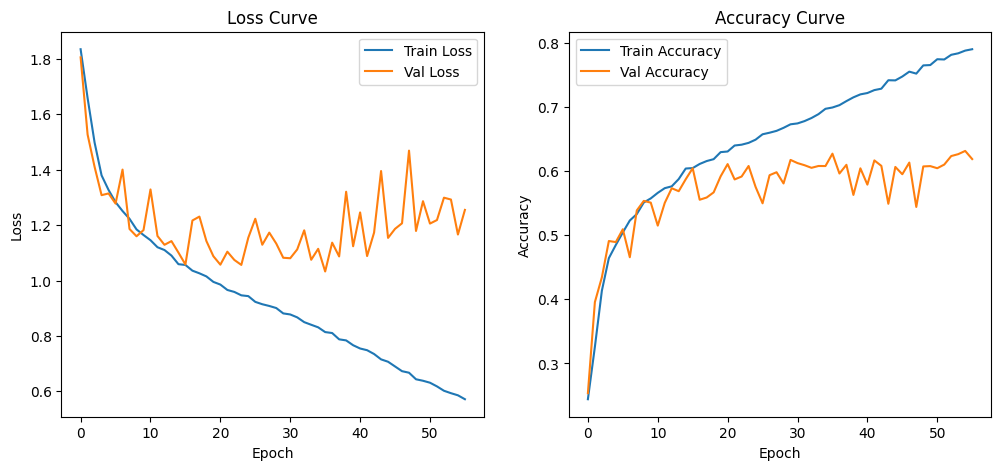

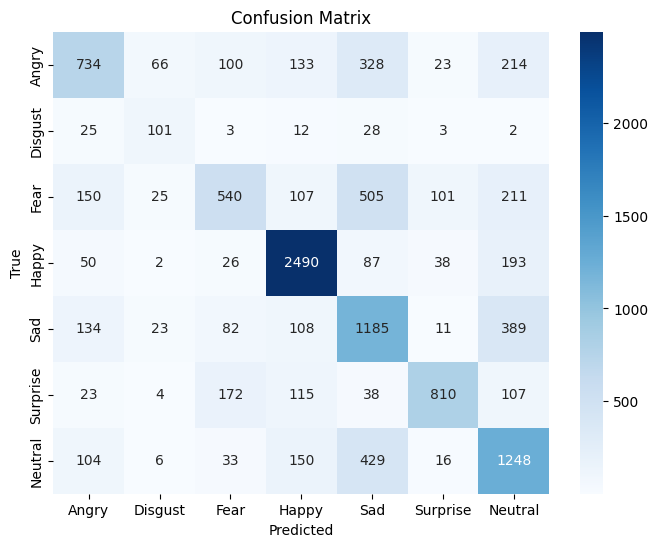

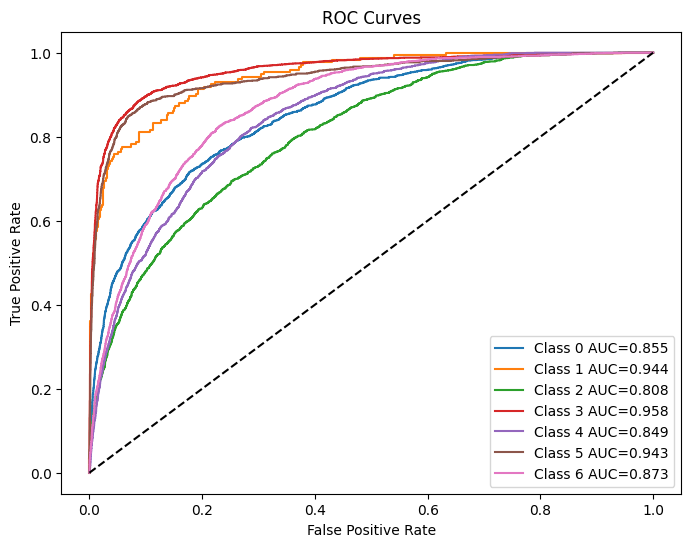

Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# =========================================================
# Imports
# =========================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from torchsummary import summary


# =========================================================
# Dataset (accept DataFrame)
# =========================================================
class FaceDataset(Dataset):
    def __init__(self, root, df, transform=None):
        self.root = root
        self.transform = transform
        self.paths = df["path"].values
        self.labels = df["label"].values

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, self.paths[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.equalizeHist(img)

        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0) / 255.0

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label


# =========================================================
# Data augmentation
# =========================================================
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(48, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])


# =========================================================
# Model: Residual Block + CNN
# =========================================================
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.conv(x)
        out = out + x
        return self.relu(out)


class FaceCNN(nn.Module):
    def __init__(self):
        super(FaceCNN, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.res1 = ResidualBlock(64)

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.res2 = ResidualBlock(128)

        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.res3 = ResidualBlock(256)

        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 7)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.res1(x)
        x = self.conv2(x)
        x = self.res2(x)
        x = self.conv3(x)
        x = self.res3(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


# =========================================================
# Early stopping
# =========================================================
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.002):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss

        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


# =========================================================
# Train
# =========================================================
def train(model, train_loader, val_loader, epochs=150, lr=0.0005, device="cuda"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()
    stopper = EarlyStopping()

    history = {"loss": [], "val_loss": [], "acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, pred = outputs.max(1)
            correct += pred.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, pred = outputs.max(1)
                val_correct += pred.eq(labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        # save history
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{epoch+1}] TrainLoss={train_loss:.4f} ValLoss={val_loss:.4f} "
              f"TrainAcc={train_acc:.4f} ValAcc={val_acc:.4f}")

        stopper(val_loss)
        if stopper.stop:
            print("\nEarly stopping triggered!!")
            break

    return history


# =========================================================
# Load Data
# =========================================================
dataset_root = "/content/face"

df = pd.read_csv(os.path.join(dataset_root, "image_emotion.csv"), header=None)
df.columns = ["path", "label"]
df["num"] = df["path"].str.extract(r"(\d+)").astype(int)
df = df.sort_values("num").reset_index(drop=True)

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])

train_dataset = FaceDataset(dataset_root, train_df, transform=train_transform)
val_dataset   = FaceDataset(dataset_root, val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = FaceCNN().to(device)

summary(model, (1, 48, 48))

history = train(model, train_loader, val_loader, epochs=150, device=device)


# =========================================================
# Plot Training Curves
# =========================================================
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history["acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


# =========================================================
# Confusion Matrix
# =========================================================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"],
    yticklabels=["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"],
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# =========================================================
# ROC Curve
# =========================================================
probs_list = []
labels_list = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)

        probs_list.extend(probs.cpu().numpy())
        labels_list.extend(labels.numpy())

probs_arr = np.array(probs_list)
labels_arr = np.array(labels_list)

# One-hot
labels_bin = label_binarize(labels_arr, classes=list(range(7)))

plt.figure(figsize=(8, 6))
for i in range(7):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probs_arr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} AUC={roc_auc:.3f}")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


# =========================================================
# Save model
# =========================================================
torch.save(model, "model_cnn.pkl")
torch.save(model.state_dict(), "model_cnn.pth")
print("Model saved!")

from google.colab import files
files.download("model_cnn.pkl")
files.download("model_cnn.pth")
